In [49]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sympy import symbols, groebner ,solve, Rational, simplify
from sympy.calculus.util import minimum
from sympy import Interval
print("x") #ver que se importa bien

x


In [104]:
# Restricciones (1-(p1+p2+p3)=0), E y V
#1-IBEX35, 2-SP500 3-EMM(mercados emergentes)
p1 = 0.3
m1 = 0.1180850933
m2 = 0.1619481497
m3 = 0.0771816605
v1 = 0.03492332644
v2 = 0.02776645397
v3 = 0.03505910984
cv12 = 0.001666029016
cv13 = 0.0005078163229
cv23 = 0.0005112105901
#lINK DE DATOS:https://docs.google.com/spreadsheets/d/1HQACoSbDBKevop9Dz-_l8LWCFvotkL9qJaM-hb5_GZ0/edit?usp=sharing
#Excel hecho por alvaro vicente bonilla y Yu Xiang Yang Xu

In [105]:
cov = np.array([
    [v1,    cv12, cv13],
    [cv12,  v2,   cv23],
    [cv13,  cv23, v3  ]
])
print(np.linalg.eigvals(cov)) #Definida positiva, sino no tienen sentido los datos

[0.02737777 0.03580042 0.0345707 ]


In [106]:
p1, p2, E, V = symbols('p1 p2 E V')

p3 = 1 - p1 - p2 ##Reestriccion, los pesos deben sumar 1, ademas de que hacemos dependiente p3 para 

E_resta = m1*p1 + m2*p2 + m3*p3# Formula de la esperanza
pol2 = E - E_resta #Igualamos a 0, con bases de grobner se trabaja con p(x) = 0

V_resta = (
    v1*p1**2 + v2*p2**2 + v3*p3**2 +
    2*cv12*p1*p2 +
    2*cv13*p1*p3 +
    2*cv23*p2*p3
)

pol3 = V - V_resta #Lo mismo para la varianza

In [107]:
G = groebner([pol2, pol3], p1, p2, E, V, order='lex') 

In [108]:
list(G)#Imprimir la base de grobner

[-24.4478258069332*E + 1.0*p1 + 2.07235636222689*p2 + 1.88692379139386,
 196.290846000649*E**2 - 24.9641116723439*E*p2 - 38.3448839154768*E - 4.76189114431982*V + 1.0*p2**2 + 2.2796724272874*p2 + 1.95716319615244]

In [109]:
E_reducido = -(1.0*p1 + 2.07235636222689*p2 + 1.88692379139386)/24.4478258069332 #Despejamos E (usaremos la version igualada a 0)

In [110]:
eq1 = -24.4478258069332*E + 1.0*p1 + 2.07235636222689*p2 + 1.88692379139386
eq2 = 196.290846000649*E**2 - 24.9641116723439*E*p2 - 38.3448839154768*E - 4.76189114431982*V + 1.0*p2**2 + 2.2796724272874*p2 + 1.95716319615244
#polinomios igualados a 0
p1_expr = solve(eq1, p1)[0] 
eq2_sub = simplify(eq2.subs(p1, p1_expr))

# 3) resolver para p2
sol_p2 = solve(eq2_sub, p2)
#Eliminamos p1 y p2
print("Soluciones para p2:")
print(sol_p2)

Soluciones para p2:
[12.482055836172*E - 5.0e-14*sqrt(-1.61956512413339e+28*E**2 + 3.95595415595753e+27*E + 1.90475645772793e+27*V - 2.63174640887533e+26) - 1.1398362136437, 12.482055836172*E + 5.0e-14*sqrt(-1.61956512413339e+28*E**2 + 3.95595415595753e+27*E + 1.90475645772793e+27*V - 2.63174640887533e+26) - 1.1398362136437]


Vemos que nos da 2 ecuaciones, recordamos que la varianza es cuadratica.
Ahora hay 2 caminos, fijar E o fijar V, vamos a ver las 2 posibilidades<br>
Si fijamos E, entonces nos queda un polinomio en funcion de V, el objetivo sera minimizar esta V<br>
Vemos 2 ecuaciones, si fijamos E, tenemos la parte superior e inferior de la elipse
Al reves para V, si dijamos V nuestro objetivo es maximizar E<br>
A diferencia de cuando fijamos E, en este caso al fijar V una de las dos soluciones no será valida o nos quedaremos con la mas alta

In [111]:
#Por ejemplo, fijemos E = 10 (suele ser un estandar bueno, ya que es la rentabilidad media del sp500 hace unos años, ahora ha subid)
E, V = sp.symbols('E V', real=True)

E_valor = 0.1

p1 = 12.482055836172*E - 5.0e-14*sp.sqrt(-1.61956512413339e+28*E**2 + 3.95595415595753e+27*E + 1.90475645772793e+27*V - 2.63174640887533e+26) - 1.1398362136437

p2 = 12.482055836172*E + 5.0e-14*sp.sqrt(-1.61956512413339e+28*E**2 + 3.95595415595753e+27*E + 1.90475645772793e+27*V - 2.63174640887533e+26) - 1.1398362136437

In [112]:
p1_E = p1.subs(E, E_valor)
p2_E = p2.subs(E, E_valor)
print(p1_E)
print("----------------")
print(p2_E)

0.1083693699735 - 5.0e-14*sqrt(1.90475645772793e+27*V - 2.9535737705119e+25)
----------------
5.0e-14*sqrt(1.90475645772793e+27*V - 2.9535737705119e+25) + 0.1083693699735


<lambdifygenerated-38>:2: RuntimeWarning: invalid value encountered in sqrt
  return 0.1083693699735 - 5.0e-14*sqrt(1.90475645772793e+27*V - 2.9535737705119e+25)


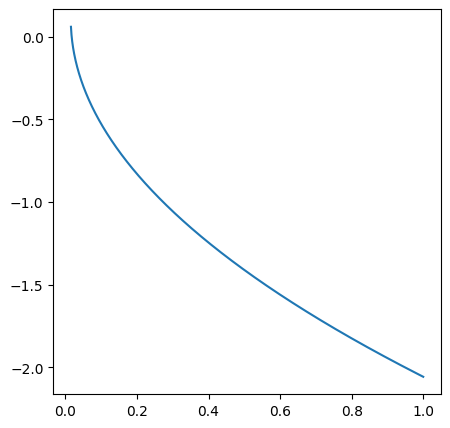

In [113]:
f =  0.1083693699735 - 5.0e-14*sp.sqrt(1.90475645772793e+27*V - 2.9535737705119e+25)
valores = np.arange(0,1, 0.0005)
f_np = sp.lambdify(V, f, "numpy")
plt.figure(figsize=(5,5))
plt.plot(valores,f_np(valores))
plt.show()

<lambdifygenerated-39>:2: RuntimeWarning: invalid value encountered in sqrt
  return 5.0e-14*sqrt(1.90475645772793e+27*V - 2.9535737705119e+25) + 0.1083693699735


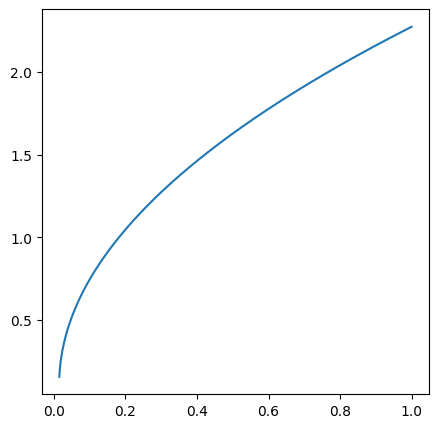

In [114]:
f2 = p2 = 5.0e-14*sp.sqrt(1.90475645772793e+27*V - 2.9535737705119e+25) + 0.1083693699735
f_np2 = sp.lambdify(V, f2, "numpy")
plt.figure(figsize=(5,5))
plt.plot(valores,f_np2(valores))
plt.show()

-47618911443198.3/sqrt(1.90475645772793e+27*V - 2.9535737705119e+25)


<lambdifygenerated-43>:2: RuntimeWarning: invalid value encountered in sqrt
  return -47618911443198.3/sqrt(1.90475645772793e+27*V - 2.9535737705119e+25)


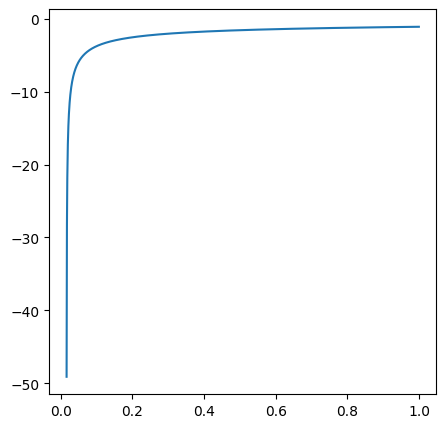

In [121]:
df1 = sp.diff(p1_E, V)
print(df1)
df1_np = sp.lambdify(V, df1, "numpy")
plt.figure(figsize=(5,5))
plt.plot(valores,df1_np(valores))
plt.show()

47618911443198.3/sqrt(1.90475645772793e+27*V - 2.9535737705119e+25)


<lambdifygenerated-44>:2: RuntimeWarning: invalid value encountered in sqrt
  return 47618911443198.3/sqrt(1.90475645772793e+27*V - 2.9535737705119e+25)


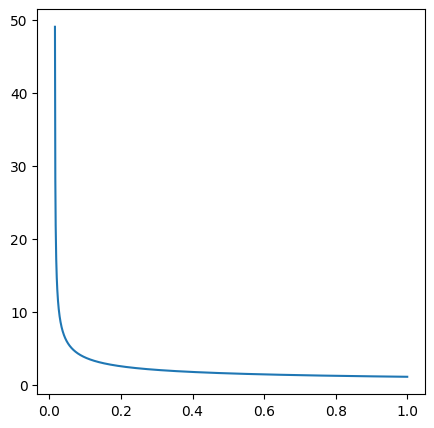

In [122]:
df2 = sp.diff(p2_E, V)
print(df2)#Misma funcion con signo negativo, por el +-
df2_np = sp.lambdify(V, df2, "numpy")
plt.figure(figsize=(5,5))
plt.plot(valores,df2_np(valores))
plt.show()

Escogemos igual a 0 y extremos (optimizacion), en la parabola vemos que en neustro caso 
el minimo V es el extremo izquierdo (donde V es positivo, en nuestro caso la segunda ecuacion)
y cogemos el primer valor posible del array que este en su dominio

In [117]:
V_min_dominio = sp.solve(1.90475645772793e+27*V - 2.9535737705119e+25, V)[0]
f2_solucion = p2 = 5.0e-14*sp.sqrt(1.90475645772793e+27*V - 2.9535737705119e+25) + 0.1083693699735
f_np2_solucion = sp.lambdify(V, f2, "numpy")
resultado = minimum(f2_solucion, V, Interval(V_min_dominio, 1))
print(float(resultado)) #Sacamos el V definido minimo de su variable,. tenemos la V, ahora sacamos p2

0.1083693699735


In [130]:
p2_sol = f_np2_solucion(float(V_min_dominio))
print(p2_sol)

0.1083693699735


In [131]:
#Un peso del sp500 del 0.77%
p3_sol = 1 - 0.3 - p2_sol
print(p3_sol)
#Un peso del 0.12% del EMM

0.5916306300265


Si fuera invalido hay que evaluar para distintas V, hasta que de positivo y se cumpla la reestriccion (es como recorrer V, vamos subiendo)

In [132]:
#Obtenemos el primer valor de V tal que p3 es positivo, asi cumplimos la reestriccion
for i in range(len(valores)):
    solucionarray=f_np2_solucion(valores[i])
    p3_sol = 1 - 0.3 - solucionarray
    if p3_sol > 0:
        indice = i
        break
print(f"el indice es: {i}, la varianza es: {valores[i]}, p2 es: {solucionarray},y p3 es: {p3_sol}")
#La precision es ajustable

el indice es: 32, la varianza es: 0.016, p2 es: 0.15685559529904688,y p3 es: 0.543144404700953
